  ### Data Ingestion and Quality Control

  The objective of this phase is to ensure data integrity before performing

  valuation analysis. We will identify missing values and verify data types

  to maintain high auditing standards.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Loading the dataset
df_unicorns = pd.read_csv("Unicorn_Companies.csv")

# Audit: Checking for structural integrity and null values
print("--- Dataset Overview ---")
df_unicorns.info()

print("\n--- Missing Values Audit ---")
print(df_unicorns.isnull().sum())

# Displaying first records for initial context
df_unicorns.head()


--- Dataset Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Company           1074 non-null   str  
 1   Valuation         1074 non-null   str  
 2   Date Joined       1074 non-null   str  
 3   Industry          1074 non-null   str  
 4   City              1058 non-null   str  
 5   Country/Region    1074 non-null   str  
 6   Continent         1074 non-null   str  
 7   Year Founded      1074 non-null   int64
 8   Funding           1074 non-null   str  
 9   Select Investors  1073 non-null   str  
dtypes: int64(1), str(9)
memory usage: 84.0 KB

--- Missing Values Audit ---
Company              0
Valuation            0
Date Joined          0
Industry             0
City                16
Country/Region       0
Continent            0
Year Founded         0
Funding              0
Select Investors     1
dtype: int64


,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,4/7/17,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,12/1/12,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,7/3/18,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,1/23/14,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,12/12/11,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."


  ### Financial Data Standardization

  To perform quantitative analysis, we need to convert string-based valuations

  into numerical formats. This process is critical for calculating market

  share and total capitalization.

In [2]:
# Cleaning 'Valuation' column: removing '$' and 'B', then converting to float
df_unicorns['Valuation_Billions'] = df_unicorns['Valuation'].str.replace('$', '').str.replace('B', '').astype(float)

# Extracting Year from 'Date Joined' to analyze growth trends over time
df_unicorns['Date Joined'] = pd.to_datetime(df_unicorns['Date Joined'])
df_unicorns['Year_Joined'] = df_unicorns['Date Joined'].dt.year

print("Data successfully standardized for financial modeling.")


Data successfully standardized for financial modeling.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_14716\632511851.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_unicorns['Date Joined'] = pd.to_datetime(df_unicorns['Date Joined'])


  ### Regional Valuation Distribution

  Leveraging the audited 'Country/Region' column to map the global

  concentration of capital.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14716\422294273.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_valuation.values, y=regional_valuation.index, palette='viridis')


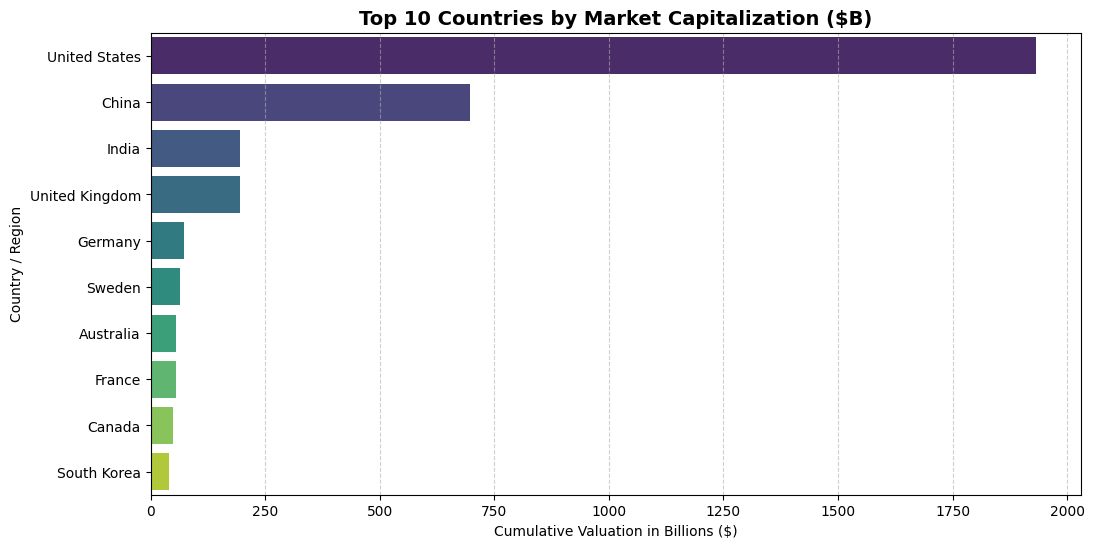

In [3]:
plt.figure(figsize=(12, 6))

# Aggregating by the correct column name identified in head()
regional_valuation = df_unicorns.groupby('Country/Region')['Valuation_Billions'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=regional_valuation.values, y=regional_valuation.index, palette='viridis')

plt.title('Top 10 Countries by Market Capitalization ($B)', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative Valuation in Billions ($)')
plt.ylabel('Country / Region')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


  ### Top 10 Unicorns by Market Valuation

  This analysis identifies the individual companies with the highest

  valuation globally, highlighting market leaders in the private sector.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14716\1419233376.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_unicorns, x='Valuation_Billions', y='Company', palette='viridis')


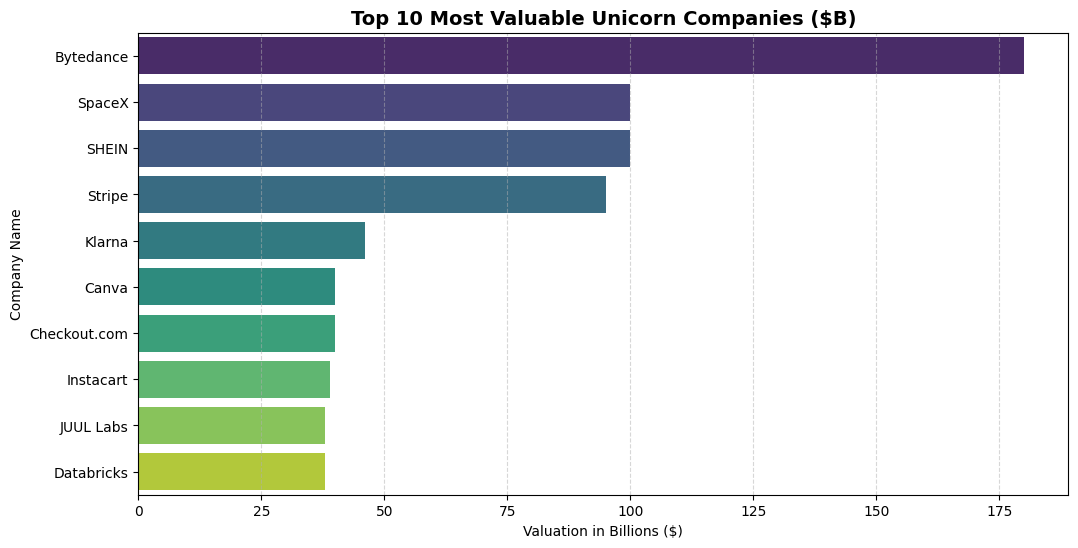

In [4]:
plt.figure(figsize=(12, 6))

# Identifying the Top 10 most valuable companies
top_unicorns = df_unicorns.sort_values(by='Valuation_Billions', ascending=False).head(10)

sns.barplot(data=top_unicorns, x='Valuation_Billions', y='Company', palette='viridis')

plt.title('Top 10 Most Valuable Unicorn Companies ($B)', fontsize=14, fontweight='bold')
plt.xlabel('Valuation in Billions ($)')
plt.ylabel('Company Name')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


  ### Industry Sector Capital Distribution (Audited)

  We are normalizing the 'Industry' column to eliminate duplicates and

  provide an accurate representation of capital allocation by sector.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14716\682248847.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_perf.values, y=industry_perf.index, palette='magma')


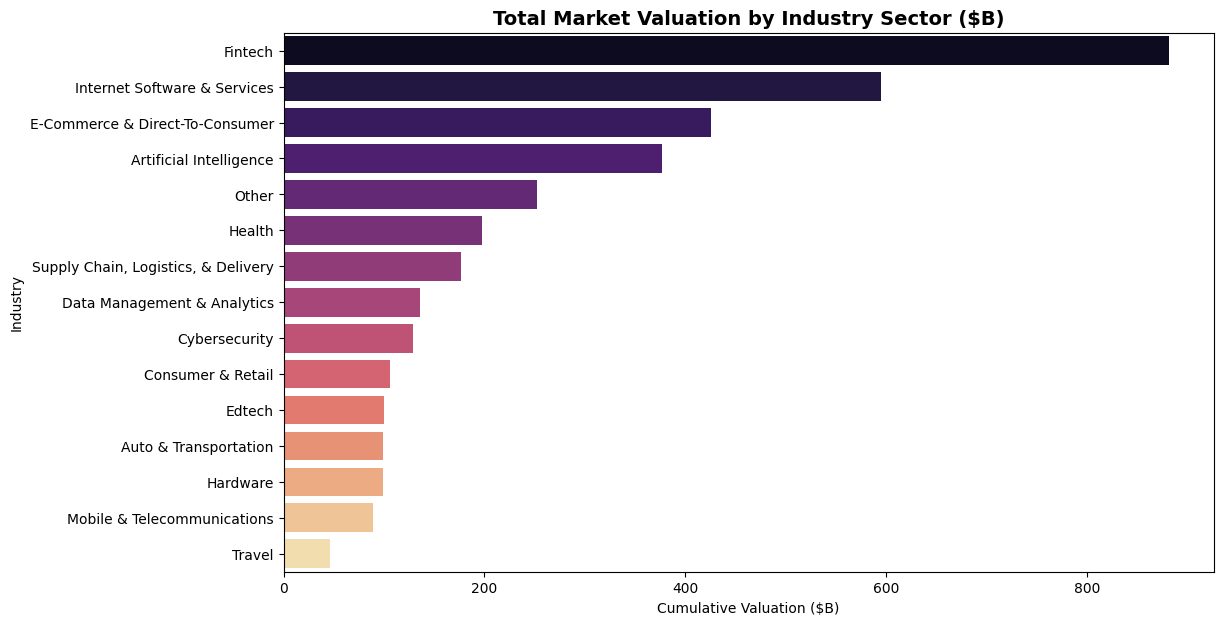

In [5]:
# Standardizing industry names to prevent duplication (e.g., AI vs Ai)
df_unicorns['Industry'] = df_unicorns['Industry'].str.strip().str.title()

plt.figure(figsize=(12, 7))

# Aggregating valuation by Industry after cleaning
industry_perf = df_unicorns.groupby('Industry')['Valuation_Billions'].sum().sort_values(ascending=False)

sns.barplot(x=industry_perf.values, y=industry_perf.index, palette='magma')

plt.title('Total Market Valuation by Industry Sector ($B)', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative Valuation ($B)')
plt.ylabel('Industry')
plt.show()


  ### Efficiency Metric: Time to Unicorn Status

  This KPI measures the years elapsed between a company's foundation

  and its entry into the Unicorn club. A shorter duration often indicates

  high market disruption or hyper-growth.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14716\2044112768.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_time_industry.values, y=avg_time_industry.index, palette='coolwarm')


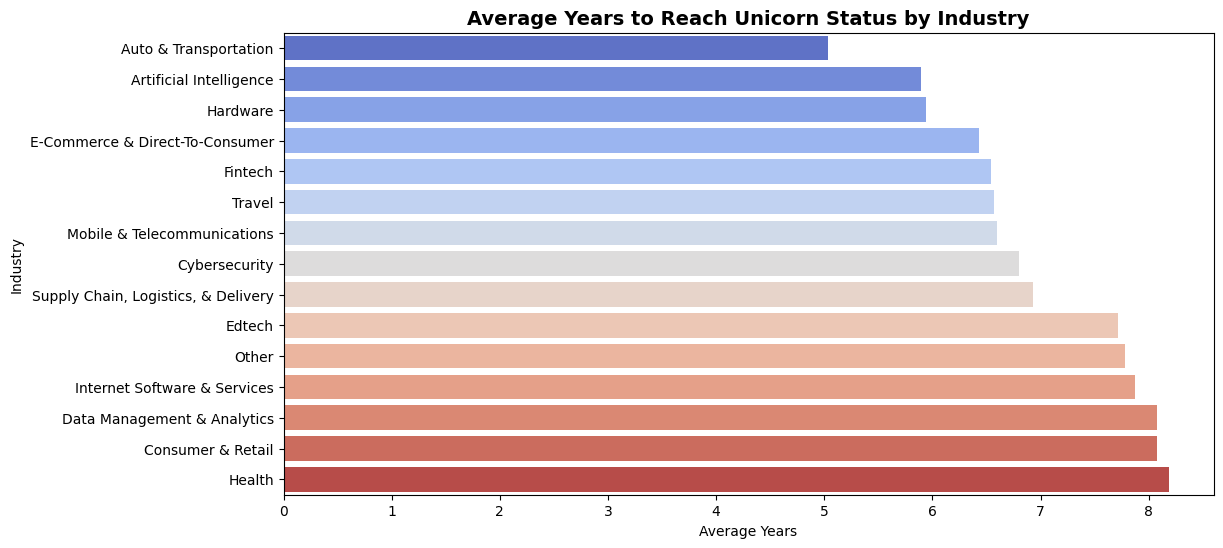

In [6]:
# 1. First, we ensure the 'Date Joined' is datetime and extract the year
df_unicorns['Year_Joined'] = pd.to_datetime(df_unicorns['Date Joined']).dt.year

# 2. We calculate the duration
df_unicorns['Years_to_Unicorn'] = df_unicorns['Year_Joined'] - df_unicorns['Year Founded']

# 3. Filtering outliers (e.g., companies with negative years due to data entry errors)
df_clean_time = df_unicorns[df_unicorns['Years_to_Unicorn'] >= 0]

# 4. Average Time to Unicorn by Industry
avg_time_industry = df_clean_time.groupby('Industry')['Years_to_Unicorn'].mean().sort_values()

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_time_industry.values, y=avg_time_industry.index, palette='coolwarm')

plt.title('Average Years to Reach Unicorn Status by Industry', fontsize=14, fontweight='bold')
plt.xlabel('Average Years')
plt.ylabel('Industry')
plt.show()


